In [199]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import skew, kurtosis

#### Análisis de la inflación de los alimentos, frecuencia mensual (fin de mes) del 30 de noviembre de 2018 al 30 de noviembre de 2025.

In [211]:
# Definición de la función para cálculo de los estadísticos

def descriptive_statistics(variable, nombre_variable):
    media = float(np.mean(variable))
    #promedio = float(np.average(variable))
    varianza = float(np.var(variable, ddof=1)) #varianza muestral
    desviacion_estandar = float(np.std(variable, ddof=1)) #desviación estándar muestral
    asimetria = float(skew(variable))
    curtosis = float(kurtosis(variable, fisher=False)) #Fisher kurtosis (excess kurtosis): normal = 0
    autocorr = float(variable.corr(variable.shift(1)))
    
    print(f'Análisis descriptivo de {nombre_variable}\nMedia: {media}\nVarianza: {varianza}\nDesviación estándar: {desviacion_estandar}\nAsimetría: {asimetria}\nCurtosis: {curtosis}\nAutocorrelación: {autocorr}\n'
      )

In [201]:
"""
Se carga el dataset de inflación de los alimentos, frecuencia mensual (fin de mes)
del 30 de noviembre de 2018 al 30 de noviembre de 2025.
"""

ds_inflacion = pd.read_excel('./data/Inflación_de_alimentos_Dato_fin_de_mes.xlsx')

# Se eliminan registros nulos y la primera fila por contener caracteres diferentes a la fecha
ds_inflacion = ds_inflacion.dropna()
ds_inflacion = ds_inflacion.iloc[1:]
ds_inflacion.rename(columns={'Inflación de alimentos(Dato fin de mes)': 'Inflacion'}, inplace=True)

# Asignación del formato fecha
ds_inflacion['Fecha'] = pd.to_datetime(ds_inflacion['Fecha'], dayfirst=True, errors='coerce')
ds_inflacion.head(5)

,Fecha,Inflacion
1,2018-11-30,"1,61"
2,2018-12-31,"1,87"
3,2019-01-31,"2,07"
4,2019-02-28,"2,29"
5,2019-03-31,"3,24"


In [202]:
# Se eliminan los registros NaT/NaN
ds_inflacion[ds_inflacion['Fecha'].isna()]
ds_inflacion = ds_inflacion.dropna(subset = ['Fecha'])
ds_inflacion

,Fecha,Inflacion
1,2018-11-30,"1,61"
2,2018-12-31,"1,87"
3,2019-01-31,"2,07"
4,2019-02-28,"2,29"
5,2019-03-31,"3,24"
...,...,...
80,2025-06-30,"4,31"
81,2025-07-31,"4,94"
82,2025-08-31,"6,13"
83,2025-09-30,"6,21"


In [203]:
# Se añaden columnas de año y mes 

ds_inflacion['Año'] = ds_inflacion['Fecha'].dt.year
ds_inflacion['Mes'] = ds_inflacion['Fecha'].dt.month

# Se seleccionan los años a analizar
years = ds_inflacion['Año'].unique()
years = years[1:] # Se seleccionan los datos de 2019 a 2024

ds_inflacion

,Fecha,Inflacion,Año,Mes
1,2018-11-30,"1,61",2018,11
2,2018-12-31,"1,87",2018,12
3,2019-01-31,"2,07",2019,1
4,2019-02-28,"2,29",2019,2
5,2019-03-31,"3,24",2019,3
...,...,...,...,...
80,2025-06-30,"4,31",2025,6
81,2025-07-31,"4,94",2025,7
82,2025-08-31,"6,13",2025,8
83,2025-09-30,"6,21",2025,9


### Análisis

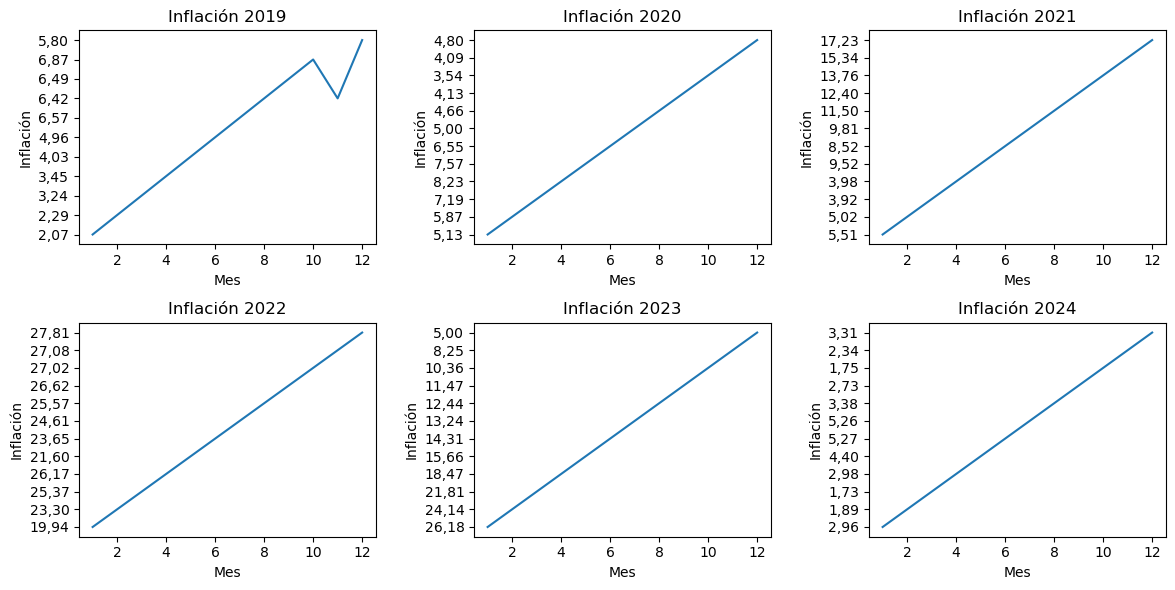

In [204]:
# Grafica temporal de la inflación 

positions = [(0,0),(0,1),(0,2),(1,0),(1,1),(1,2)]

fig, axs = plt.subplots(2,3, figsize=(12,6))

for (row,col), year in zip(positions, years):
    ax = axs[row,col]
    data = ds_inflacion[ds_inflacion['Año'] == year]
    ax.plot(data['Mes'], data['Inflacion'])
    ax.set_title(f"Inflación {year}")
    ax.set_xlabel("Mes")
    ax.set_ylabel("Inflación")

plt.tight_layout()
plt.show()



##### Se intentó sacar los estadísticos a la serie temporal, sin embargo no fue posible por la poca cantidad de puntos temporales disponibles. El dato mensual genera gráficas muy cortas para extraer métricas como la varianza y la kurtosis.

#### Análisis de las captaciones a través de CDT por red de oficinas, frecuencia diaria.

In [205]:
ds_cdt = pd.read_excel('./data/Captaciones_CDT_red_de_oficinas_Monto_diaria.xlsx')
ds_cdt.head(5)

,Fecha,"Captaciones a través de CDT por red de oficinas - Monto, diaria(Dato diario)"
0,dd/mm/aaaa,Millones de COP
1,01/04/2008,"197.723,83"
2,02/04/2008,"198.214,76"
3,03/04/2008,"174.669,12"
4,04/04/2008,"218.778,94"


In [206]:
# Se eliminan registros nulos y la primera fila por contener caracteres diferentes a la fecha
ds_cdt = ds_cdt.dropna()
ds_cdt = ds_cdt.iloc[1:]
ds_cdt.rename(columns={'Captaciones a través de CDT por red de oficinas - Monto, diaria(Dato diario)': 'Captaciones M_COP'}, inplace=True)

# Asignación del formato fecha
ds_cdt['Fecha'] = pd.to_datetime(ds_cdt['Fecha'], dayfirst=True, errors='coerce')

# Asignación del formato número, se eliminan los puntos y las comas
ds_cdt['Captaciones M_COP'] = ds_cdt['Captaciones M_COP'].str.replace('.','', regex=False).str.replace(',','',regex=False).astype(float)

ds_cdt.head(5)

,Fecha,Captaciones M_COP
1,2008-04-01,19772383.0
2,2008-04-02,19821476.0
3,2008-04-03,17466912.0
4,2008-04-04,21877894.0
5,2008-04-07,24745154.0


In [207]:
# Se eliminan los registros NaT/NaN
ds_cdt[ds_cdt['Fecha'].isna()]
ds_cdt = ds_cdt.dropna(subset = ['Fecha'])
ds_cdt.head(5)

,Fecha,Captaciones M_COP
1,2008-04-01,19772383.0
2,2008-04-02,19821476.0
3,2008-04-03,17466912.0
4,2008-04-04,21877894.0
5,2008-04-07,24745154.0


In [208]:
# Se añaden columnas de año y mes 

ds_cdt['Año'] = ds_cdt['Fecha'].dt.year
ds_cdt['Mes'] = ds_cdt['Fecha'].dt.month

# Se seleccionan los años a analizar
years = ds_cdt['Año'].unique()
years = years[11:17] # Se seleccionan los datos de 2019 a 2024

ds_cdt

,Fecha,Captaciones M_COP,Año,Mes
1,2008-04-01,19772383.0,2008,4
2,2008-04-02,19821476.0,2008,4
3,2008-04-03,17466912.0,2008,4
4,2008-04-04,21877894.0,2008,4
5,2008-04-07,24745154.0,2008,4
...,...,...,...,...
4320,2025-11-21,162230846.0,2025,11
4321,2025-11-24,196145138.0,2025,11
4322,2025-11-25,141032046.0,2025,11
4323,2025-11-26,129312591.0,2025,11


## Análisis

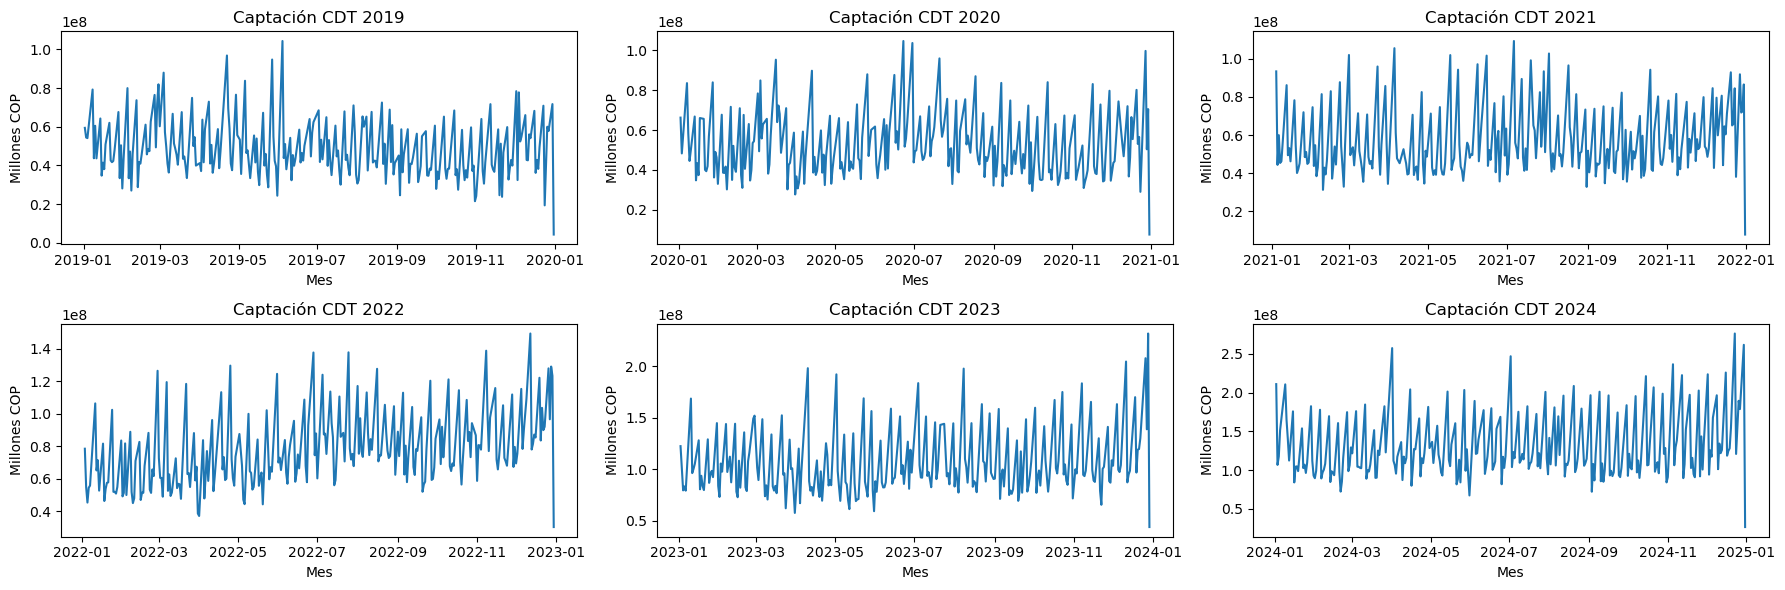

In [209]:
# Grafica temporal de la captación de CDTs

positions = [(0,0),(0,1),(0,2),(1,0),(1,1),(1,2)]

fig, axs = plt.subplots(2,3, figsize=(18,6))

for (row,col), year in zip(positions, years):
    ax = axs[row,col]
    data = ds_cdt[ds_cdt['Año'] == year]
    ax.plot(data['Fecha'], data['Captaciones M_COP'])
    ax.set_title(f"Captación CDT {year}")
    ax.set_xlabel("Mes")
    ax.set_ylabel("Millones COP")

plt.tight_layout()
plt.show()

In [212]:
for y in years:
    print(f"{y}")
    data = ds_cdt[ds_cdt['Año'] == y]['Captaciones M_COP']
    descriptive_statistics(data, 'Captaciones M_COP')

2019
Análisis descriptivo de Captaciones M_COP
Media: 48116869.18699187
Varianza: 223600230843329.28
Desviación estándar: 14953268.232842254
Asimetría: 0.7519970016385668
Curtosis: 3.814958093695742
Autocorrelación: -0.09471701729391772

2020
Análisis descriptivo de Captaciones M_COP
Media: 51174066.016393445
Varianza: 260868536631363.03
Desviación estándar: 16151425.219817694
Asimetría: 0.8952629556685039
Curtosis: 3.597365293635502
Autocorrelación: -0.04097687097936645

2021
Análisis descriptivo de Captaciones M_COP
Media: 55820787.6300813
Varianza: 309146502027638.8
Desviación estándar: 17582562.442023028
Asimetría: 1.0209627984981586
Curtosis: 3.4798893569510607
Autocorrelación: -0.15308755691699663

2022
Análisis descriptivo de Captaciones M_COP
Media: 76874668.5894309
Varianza: 501974880797503.9
Desviación estándar: 22404795.93295828
Asimetría: 0.8167305027511658
Curtosis: 3.249115333314286
Autocorrelación: 0.11407930955397798

2023
Análisis descriptivo de Captaciones M_COP
Media

El proceso evaluado no es estacionario porque la media y la varianza no son constantes, de hecho la media presenta tendencia alcista con los años. La varianza también cambia, aumenta con el tiempo.
Los valores de autocorrelación son muy pequeños, no hay una fuerte dependencia entre un valor y el siguiente.